In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow import keras

from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import TensorFlowV2Classifier
from keras import layers

In [39]:
(_, _), (x_test, y_test) = cifar10.load_data()
X_test = x_test.astype("float32") / 255.0
y_test = y_test.flatten()

# X_test = X_test.reshape(-1, 32, 32, 3).astype('float32') / 255.0
y_test = np.array(y_test)

In [40]:


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(10, activation="softmax")
])

# Load just the weights
model.load_weights("model.keras")

classifier = TensorFlowV2Classifier(
    model=model,
    loss_object=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    nb_classes=10,
    input_shape=(32, 32, 3),
    clip_values=(0, 1),
)

In [41]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

def fgsm_attack(model, images, labels, eps=8/255):
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.int32)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = loss_fn(labels, predictions)

    grad       = tape.gradient(loss, images)
    adv_images = images + eps * tf.sign(grad)
    adv_images = tf.clip_by_value(adv_images, 0.0, 1.0)
    return adv_images

In [42]:
EPS = 8 / 255
N   = 1000

x_sample = x_test[:N]
y_sample  = y_test[:N]

# --- Baseline: czysta dokładność ---
clean_preds = np.argmax(classifier.predict(x_sample), axis=1)
clean_acc   = np.mean(clean_preds == y_sample)

# --- ART FGSM ---
art_attack  = FastGradientMethod(estimator=classifier, eps=EPS)
x_adv_art   = art_attack.generate(x=x_sample)
art_preds   = np.argmax(classifier.predict(x_adv_art), axis=1)
art_acc     = np.mean(art_preds == y_sample)

# --- Własna implementacja FGSM ---
x_adv_own  = fgsm_attack(model, x_sample, y_sample, eps=EPS).numpy()
own_preds  = np.argmax(classifier.predict(x_adv_own), axis=1)
own_acc    = np.mean(own_preds == y_sample)

print(f"Clean accuracy      : {clean_acc:.4f}")
print(f"ART FGSM accuracy   : {art_acc:.4f}  (eps={EPS:.4f})")
print(f"Own FGSM accuracy   : {own_acc:.4f}  (eps={EPS:.4f})")

Clean accuracy      : 0.3950
ART FGSM accuracy   : 0.3950  (eps=0.0314)
Own FGSM accuracy   : 0.1070  (eps=0.0314)


## Targeted and untargeted attack

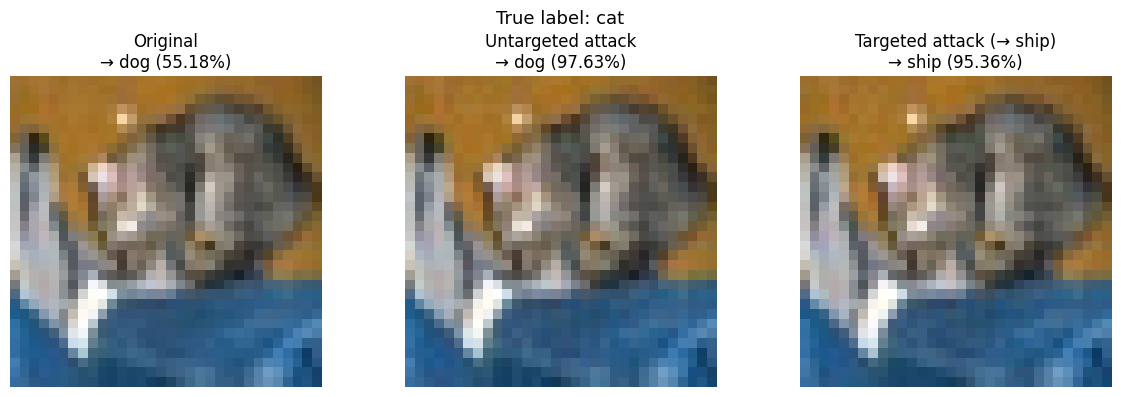

In [43]:
from matplotlib import pyplot as plt

# Pick a single test image
idx = 0
image = X_test[idx:idx+1]  # shape (1, 32, 32, 3)
true_label = y_test[idx]

cifar10_classes = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

epsilon = 0.01  # attack strength

def get_prediction(img):
    pred = model.predict(img, verbose=0)
    return np.argmax(pred), np.max(pred)

def fgsm_untargeted(image, true_label, epsilon):
    image_tensor = tf.Variable(image, dtype=tf.float32)
    label_tensor = tf.cast([true_label], tf.int32)
    with tf.GradientTape() as tape:
        pred = model(image_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label_tensor, pred)
    gradient = tape.gradient(loss, image_tensor)
    perturbation = epsilon * tf.sign(gradient)
    adv_image = tf.clip_by_value(image_tensor + perturbation, 0, 1)
    return adv_image.numpy()

def fgsm_targeted(image, target_label, epsilon):
    image_tensor = tf.Variable(image, dtype=tf.float32)
    label_tensor = tf.cast([target_label], tf.int32)
    with tf.GradientTape() as tape:
        pred = model(image_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label_tensor, pred)
    gradient = tape.gradient(loss, image_tensor)
    perturbation = epsilon * tf.sign(gradient)
    adv_image = tf.clip_by_value(image_tensor - perturbation, 0, 1)
    return adv_image.numpy()

target_label = 8  # force model to predict "ship" (pick anything != true_label)

adv_untargeted = fgsm_untargeted(image, true_label, epsilon)
adv_targeted   = fgsm_targeted(image, target_label, epsilon)

orig_class,    orig_conf    = get_prediction(image)
untarg_class,  untarg_conf  = get_prediction(adv_untargeted)
targ_class,    targ_conf    = get_prediction(adv_targeted)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image[0])
axes[0].set_title(f"Original\n→ {cifar10_classes[orig_class]} ({orig_conf:.2%})")

axes[1].imshow(adv_untargeted[0].squeeze())
axes[1].set_title(f"Untargeted attack\n→ {cifar10_classes[untarg_class]} ({untarg_conf:.2%})")

axes[2].imshow(adv_targeted[0].squeeze())
axes[2].set_title(f"Targeted attack (→ {cifar10_classes[target_label]})\n→ {cifar10_classes[targ_class]} ({targ_conf:.2%})")

for ax in axes:
    ax.axis('off')

plt.suptitle(f"True label: {cifar10_classes[true_label]}", fontsize=13)
plt.tight_layout()
plt.show()

## Epsilon minimalization

True label: cat (3)

UNTARGETED — binary search
iter  1 | ε=0.250000 | → frog (76.66%) | ✓ fooled
iter  2 | ε=0.125000 | → frog (49.64%) | ✗ failed
iter  3 | ε=0.187500 | → frog (64.27%) | ✓ fooled
iter  4 | ε=0.156250 | → frog (58.29%) | ✓ fooled
iter  5 | ε=0.140625 | → frog (56.07%) | ✓ fooled
iter  6 | ε=0.132812 | → frog (53.82%) | ✓ fooled
iter  7 | ε=0.128906 | → frog (51.54%) | ✓ fooled
iter  8 | ε=0.126953 | → frog (50.39%) | ✓ fooled
iter  9 | ε=0.125977 | → frog (49.98%) | ✗ failed
iter 10 | ε=0.126465 | → frog (50.18%) | ✓ fooled
iter 11 | ε=0.126221 | → frog (50.07%) | ✓ fooled
iter 12 | ε=0.126099 | → frog (50.02%) | ✓ fooled
iter 13 | ε=0.126038 | → frog (50.00%) | ✓ fooled
iter 14 | ε=0.126007 | → frog (49.99%) | ✗ failed
iter 15 | ε=0.126022 | → frog (50.00%) | ✗ failed
iter 16 | ε=0.126030 | → frog (50.00%) | ✗ failed
iter 17 | ε=0.126034 | → frog (50.00%) | ✓ fooled
iter 18 | ε=0.126032 | → frog (50.00%) | ✗ failed
iter 19 | ε=0.126033 | → frog (50.00%) | ✓ fooled
it

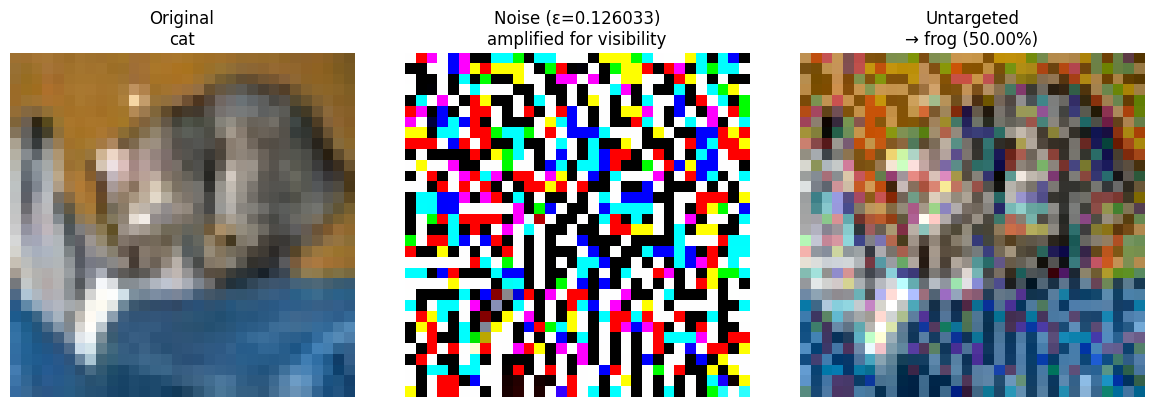

✗ Targeted attack failed — try increasing eps_max


In [44]:
def find_min_epsilon_untargeted(image, true_label, eps_min=0.0, eps_max=0.5, iterations=20, confidence_threshold=0.5):
    """Binary search for smallest epsilon that fools the model."""

    best_eps = eps_max
    best_adv = None

    for i in range(iterations):
        eps_mid = (eps_min + eps_max) / 2
        adv = fgsm_untargeted(image, true_label, eps_mid)
        pred_class, pred_conf = get_prediction(adv)

        success = (pred_class != true_label) and (pred_conf >= confidence_threshold)

        print(f"iter {i+1:2d} | ε={eps_mid:.6f} | → {cifar10_classes[pred_class]} ({pred_conf:.2%}) | {'✓ fooled' if success else '✗ failed'}")

        if success:
            best_eps = eps_mid
            best_adv = adv
            eps_max = eps_mid  # try smaller
        else:
            eps_min = eps_mid  # need bigger

    return best_eps, best_adv


def find_min_epsilon_targeted(image, true_label, target_label, eps_min=0.0, eps_max=0.5, iterations=20, confidence_threshold=0.5):
    """Binary search for smallest epsilon that forces target class."""

    best_eps = eps_max
    best_adv = None

    for i in range(iterations):
        eps_mid = (eps_min + eps_max) / 2
        adv = fgsm_targeted(image, target_label, eps_mid)
        pred_class, pred_conf = get_prediction(adv)

        success = (pred_class == target_label) and (pred_conf >= confidence_threshold)

        print(f"iter {i+1:2d} | ε={eps_mid:.6f} | → {cifar10_classes[pred_class]} ({pred_conf:.2%}) | {'✓ fooled' if success else '✗ failed'}")

        if success:
            best_eps = eps_mid
            best_adv = adv
            eps_max = eps_mid  # try smaller
        else:
            eps_min = eps_mid  # need bigger

    return best_eps, best_adv


# --- Run optimization ---
print(f"True label: {cifar10_classes[true_label]} ({true_label})")
print(f"\n{'='*55}")
print("UNTARGETED — binary search")
print('='*55)
best_eps_u, best_adv_u = find_min_epsilon_untargeted(image, true_label)

print(f"\n{'='*55}")
print(f"TARGETED (→ {cifar10_classes[target_label]}) — binary search")
print('='*55)
best_eps_t, best_adv_t = find_min_epsilon_targeted(image, true_label, target_label)


# --- Noise visualization ---
def visualize_optimized(image, adv, best_eps, attack_name, pred_class, pred_conf):
    noise = adv[0] - image[0]
    noise_amplified = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image[0])
    axes[0].set_title(f"Original\n{cifar10_classes[true_label]}")

    axes[1].imshow(noise_amplified)
    axes[1].set_title(f"Noise (ε={best_eps:.6f})\namplified for visibility")

    axes[2].imshow(np.clip(adv[0], 0, 1))
    axes[2].set_title(f"{attack_name}\n→ {cifar10_classes[pred_class]} ({pred_conf:.2%})")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Final predictions at best epsilon
if best_adv_u is not None:
    cls_u, conf_u = get_prediction(best_adv_u)
    print(f"\n✓ Best untargeted ε = {best_eps_u:.6f} → {cifar10_classes[cls_u]} ({conf_u:.2%})")
    visualize_optimized(image, best_adv_u, best_eps_u, "Untargeted", cls_u, conf_u)
else:
    print("\n✗ Untargeted attack failed — try increasing eps_max")

if best_adv_t is not None:
    cls_t, conf_t = get_prediction(best_adv_t)
    print(f"✓ Best targeted  ε = {best_eps_t:.6f} → {cifar10_classes[cls_t]} ({conf_t:.2%})")
    visualize_optimized(image, best_adv_t, best_eps_t, f"Targeted→{cifar10_classes[target_label]}", cls_t, conf_t)
else:
    print("✗ Targeted attack failed — try increasing eps_max")

## SSIM

True label: cat

Baseline SSIM (original vs itself): 1.000000

Attack:    Untargeted FGSM (ε=0.126033)
Result:    cat → frog (50.00%)
Success:   ✓ YES
─────────────────────────────────────────────
L2 norm:   6.9612   (lower = less total noise)
L_inf:     0.126033 (lower = smaller max pixel change)
SSIM:      0.617430 (closer to 1.0 = more imperceptible)


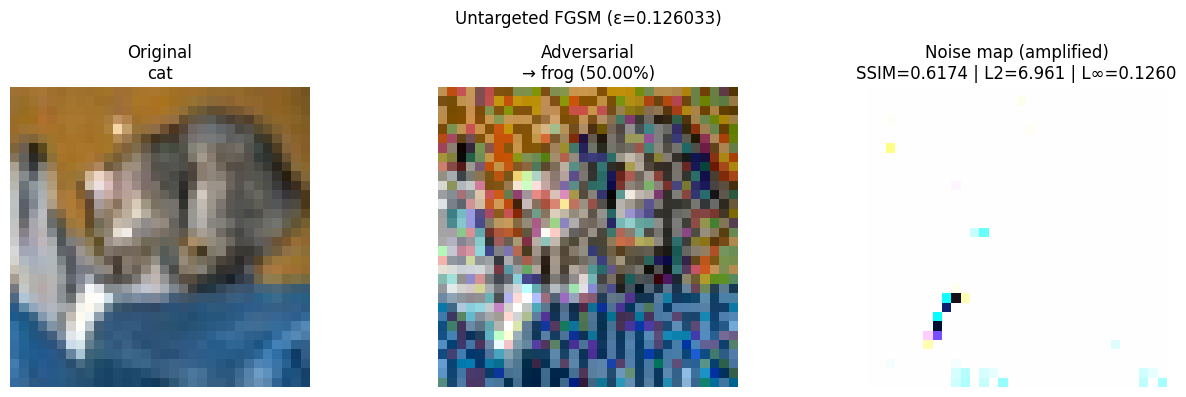

In [45]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def compute_metrics(original, adversarial):
    """
    Compute L2, L_inf, and SSIM between original and adversarial image.
    Inputs: numpy arrays of shape (1, 32, 32, 3), values in [0, 1]
    """
    orig = original[0]   # (32, 32, 3)
    adv  = adversarial[0]

    noise = adv - orig

    l2   = np.linalg.norm(noise)
    linf = np.max(np.abs(noise))
    ssim_score = ssim(orig, adv, data_range=1.0, channel_axis=2)

    return {"L2": l2, "L_inf": linf, "SSIM": ssim_score}


def evaluate_attack(name, original, adversarial, true_label, target_label=None):
    metrics = compute_metrics(original, adversarial)
    pred_class, pred_conf = get_prediction(adversarial)

    success = (pred_class != true_label) if target_label is None \
              else (pred_class == target_label)

    print(f"\n{'='*45}")
    print(f"Attack:    {name}")
    print(f"Result:    {cifar10_classes[true_label]} → {cifar10_classes[pred_class]} ({pred_conf:.2%})")
    print(f"Success:   {'✓ YES' if success else '✗ NO'}")
    print(f"─────────────────────────────────────────────")
    print(f"L2 norm:   {metrics['L2']:.4f}   (lower = less total noise)")
    print(f"L_inf:     {metrics['L_inf']:.6f} (lower = smaller max pixel change)")
    print(f"SSIM:      {metrics['SSIM']:.6f} (closer to 1.0 = more imperceptible)")
    print(f"{'='*45}")

    return metrics


# --- Evaluate all attacks ---
print(f"True label: {cifar10_classes[true_label]}\n")

# Original vs itself — perfect baseline
baseline = compute_metrics(image, image)
print(f"Baseline SSIM (original vs itself): {baseline['SSIM']:.6f}")  # should be 1.0

# Untargeted at best epsilon
if best_adv_u is not None:
    metrics_u = evaluate_attack(
        f"Untargeted FGSM (ε={best_eps_u:.6f})",
        image, best_adv_u, true_label
    )

# Targeted at best epsilon
if best_adv_t is not None:
    metrics_t = evaluate_attack(
        f"Targeted FGSM → {cifar10_classes[target_label]} (ε={best_eps_t:.6f})",
        image, best_adv_t, true_label, target_label
    )


# --- Visual comparison of noise ---
def plot_ssim_analysis(original, adversarial, attack_name, metrics):
    orig = original[0]
    adv  = adversarial[0]
    noise = np.abs(adv - orig)
    noise_amplified = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(np.clip(orig, 0, 1))
    axes[0].set_title(f"Original\n{cifar10_classes[true_label]}")

    axes[1].imshow(np.clip(adv, 0, 1))
    pred_class, pred_conf = get_prediction(adversarial)
    axes[1].set_title(f"Adversarial\n→ {cifar10_classes[pred_class]} ({pred_conf:.2%})")

    axes[2].imshow(noise_amplified, cmap='hot')
    axes[2].set_title(
        f"Noise map (amplified)\n"
        f"SSIM={metrics['SSIM']:.4f} | L2={metrics['L2']:.3f} | L∞={metrics['L_inf']:.4f}"
    )

    for ax in axes:
        ax.axis('off')

    plt.suptitle(attack_name, fontsize=12)
    plt.tight_layout()
    plt.show()


if best_adv_u is not None:
    plot_ssim_analysis(image, best_adv_u, f"Untargeted FGSM (ε={best_eps_u:.6f})", metrics_u)

if best_adv_t is not None:
    plot_ssim_analysis(image, best_adv_t, f"Targeted FGSM → {cifar10_classes[target_label]}", metrics_t)

## PGD vs FGSM


Attack:   FGSM (ART)
Result:   cat → cat (52.46%)
Success:  ✗ NO
──────────────────────────────────────────────────
L2:       6.9554
L∞:       0.126033
SSIM:     0.614597  (1.0 = imperceptible)

Attack:   PGD  (ART)
Result:   cat → cat (100.00%)
Success:  ✗ NO
──────────────────────────────────────────────────
L2:       4.5645
L∞:       0.126033
SSIM:     0.806910  (1.0 = imperceptible)

╔══════════════════╦══════════════════╦══════════════════╗
║ Metric           ║ FGSM             ║ PGD              ║
╠══════════════════╬══════════════════╬══════════════════╣
║ Prediction       ║ cat              ║ cat              ║
║ Confidence       ║ 52.46%           ║ 100.00%          ║
║ L2               ║ 6.9554           ║ 4.5645           ║
║ L∞               ║ 0.126033         ║ 0.126033         ║
║ SSIM             ║ 0.614597         ║ 0.806910         ║
╚══════════════════╩══════════════════╩══════════════════╝



2026-03-29 09:47:53.756229: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


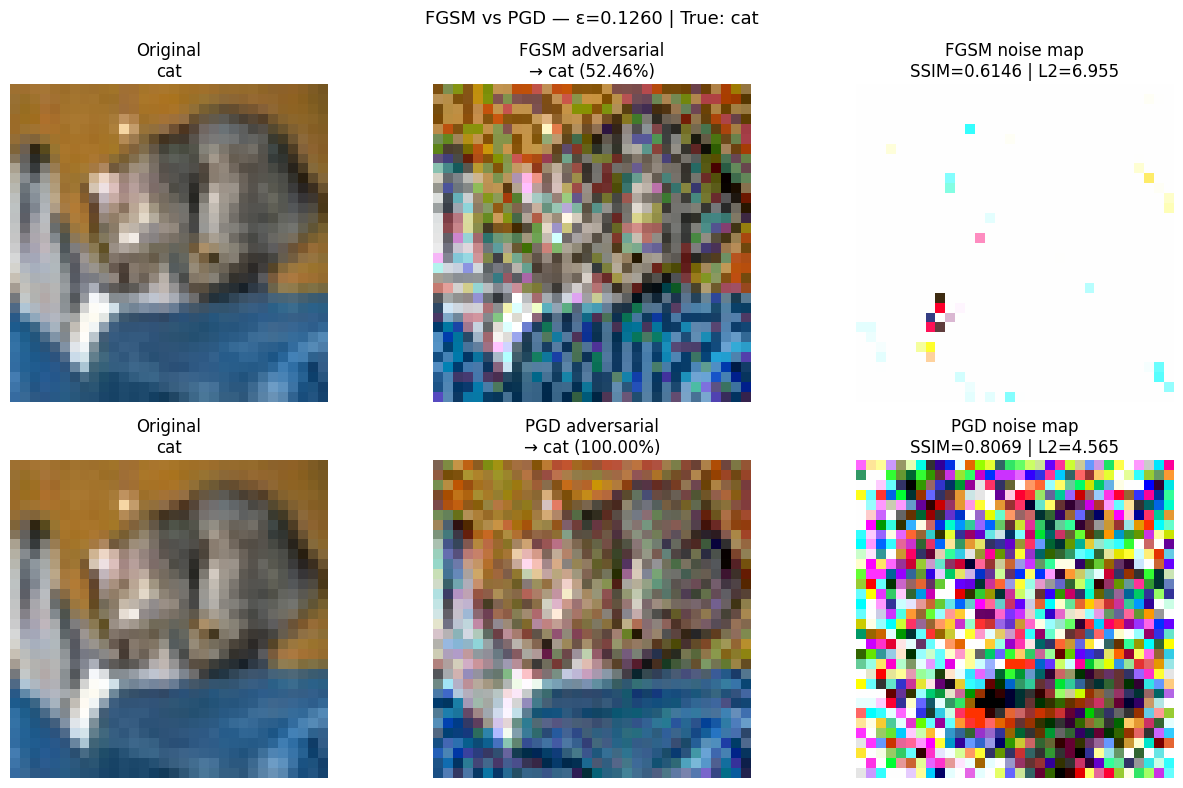

In [46]:
# pip install adversarial-robustness-toolbox
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# --- Wrap model in ART classifier ---
classifier = TensorFlowV2Classifier(
    model=model,
    loss_object=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    nb_classes=10,
    input_shape=(32, 32, 3),
    clip_values=(0, 1),
)

# --- ART FGSM ---
fgsm_art = FastGradientMethod(
    estimator=classifier,
    eps=best_eps_u,          # use same epsilon found by binary search
    targeted=False,
)

# --- ART PGD ---
pgd_art = ProjectedGradientDescent(
    estimator=classifier,
    eps=best_eps_u,          # same epsilon budget as FGSM — fair comparison
    eps_step=best_eps_u / 10,  # step size per iteration
    max_iter=40,
    targeted=False,
    verbose=False,
)

# --- Generate adversarial examples ---
x_input = image.copy()  # shape (1, 32, 32, 3), normalized [0,1]
y_input = np.array([true_label])

adv_fgsm = fgsm_art.generate(x=x_input)
adv_pgd  = pgd_art.generate(x=x_input)


# --- Metrics helper ---
def compute_metrics(original, adversarial):
    orig  = original[0]
    adv   = adversarial[0]
    noise = adv - orig
    return {
        "L2":   np.linalg.norm(noise),
        "Linf": np.max(np.abs(noise)),
        "SSIM": ssim(orig, adv, data_range=1.0, channel_axis=2),
    }

def get_prediction(img):
    pred = model.predict(img, verbose=0)
    return np.argmax(pred), np.max(pred)


# --- Evaluate & compare ---
def evaluate(name, original, adversarial, true_label):
    metrics = compute_metrics(original, adversarial)
    pred_class, pred_conf = get_prediction(adversarial)
    success = pred_class != true_label

    print(f"\n{'='*50}")
    print(f"Attack:   {name}")
    print(f"Result:   {cifar10_classes[true_label]} → {cifar10_classes[pred_class]} ({pred_conf:.2%})")
    print(f"Success:  {'✓ YES' if success else '✗ NO'}")
    print(f"──────────────────────────────────────────────────")
    print(f"L2:       {metrics['L2']:.4f}")
    print(f"L∞:       {metrics['Linf']:.6f}")
    print(f"SSIM:     {metrics['SSIM']:.6f}  (1.0 = imperceptible)")
    print(f"{'='*50}")
    return metrics, pred_class, pred_conf


m_fgsm, cls_fgsm, conf_fgsm = evaluate("FGSM (ART)", image, adv_fgsm, true_label)
m_pgd,  cls_pgd,  conf_pgd  = evaluate("PGD  (ART)", image, adv_pgd,  true_label)


# --- Summary comparison table ---
print(f"""
╔══════════════════╦══════════════════╦══════════════════╗
║ Metric           ║ FGSM             ║ PGD              ║
╠══════════════════╬══════════════════╬══════════════════╣
║ Prediction       ║ {cifar10_classes[cls_fgsm]:<16} ║ {cifar10_classes[cls_pgd]:<16} ║
║ Confidence       ║ {conf_fgsm:<16.2%} ║ {conf_pgd:<16.2%} ║
║ L2               ║ {m_fgsm['L2']:<16.4f} ║ {m_pgd['L2']:<16.4f} ║
║ L∞               ║ {m_fgsm['Linf']:<16.6f} ║ {m_pgd['Linf']:<16.6f} ║
║ SSIM             ║ {m_fgsm['SSIM']:<16.6f} ║ {m_pgd['SSIM']:<16.6f} ║
╚══════════════════╩══════════════════╩══════════════════╝
""")


# --- Visual comparison ---
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row, (adv, name, cls, conf, metrics) in enumerate([
    (adv_fgsm, "FGSM", cls_fgsm, conf_fgsm, m_fgsm),
    (adv_pgd,  "PGD",  cls_pgd,  conf_pgd,  m_pgd),
]):
    noise = np.abs(adv[0] - image[0])
    noise_vis = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)

    axes[row, 0].imshow(np.clip(image[0], 0, 1))
    axes[row, 0].set_title(f"Original\n{cifar10_classes[true_label]}")

    axes[row, 1].imshow(np.clip(adv[0], 0, 1))
    axes[row, 1].set_title(f"{name} adversarial\n→ {cifar10_classes[cls]} ({conf:.2%})")

    axes[row, 2].imshow(noise_vis, cmap='hot')
    axes[row, 2].set_title(f"{name} noise map\nSSIM={metrics['SSIM']:.4f} | L2={metrics['L2']:.3f}")

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle(f"FGSM vs PGD — ε={best_eps_u:.4f} | True: {cifar10_classes[true_label]}", fontsize=13)
plt.tight_layout()
plt.show()